In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
data=pd.read_csv('transactn1.csv')
data1=pd.read_csv('Credit_transaction.csv')
data2=pd.read_csv('Risk_txn_time.csv')
data.head()
#data.info()

,Transaction_ID,Customer_ID,Branch,Transaction_Date,Transaction_Type,Amount,Currency,Status,Amount_in_INR
0,TXN833420,CUST2665,TRIVANDRUM,2023-01-07,DEPOSIT,389650.0,INR,UNKNOWN,389650.0
1,TXN659381,CUST9640,CHENNAI,2019-01-12,WITHDRAWAL,3793001.0,USD,PENDING,314819083.0
2,TXN880101,CUST3248,CALICUT,2018-01-16,WITHDRAWAL,2160839.0,INR,UNKNOWN,2160839.0
3,TXN823601,CUST2120,KOCHI,2020-12-18,WITHDRAWAL,1180522.0,USD,SUCCESS,97983326.0
4,TXN318577,CUST2707,TRIVANDRUM,2021-09-20,WITHDRAWAL,4326846.0,INR,PENDING,4326846.0


In [5]:
#data type

data['Transaction_Date']=pd.to_datetime(data['Transaction_Date'])
data['Month']=data['Transaction_Date'].dt.to_period('M')

#Compute metrics

trend=data.groupby('Month').agg({
    'Transaction_ID':'count',
    'Amount_in_INR':['sum','mean']
})

trend.columns=['Volume','Total_value','Avg_value']
trend=trend.reset_index()

trend['Growth_rate']=trend['Total_value'].pct_change()*100

trend['Moving_average']=trend['Total_value'].rolling(window=3).mean()

Success_trend=(data[data['Status']=='SUCCESS'].groupby('Month').agg(
    Success_volume=('Transaction_ID','count'),
    Success_value=('Amount_in_INR','sum')
)
               .reset_index()
              )

trend=trend.merge(Success_trend, on='Month', how='left')               
#trend['Success_value']=(data[data['Status']=='SUCCESS'].groupby('Month')['Amount_in_INR'].sum().reindex(trend['Month']))

trend['Success_rate_vol']=(trend['Success_volume']/trend['Volume'])*100

trend['Success_rate_val']=(trend['Success_value']/trend['Total_value'])*100

trend['Value_per_transaction']=(trend['Total_value']/trend['Volume'])
print(trend)

      Month  Volume   Total_value     Avg_value  Growth_rate  Moving_average  \
0   2018-01     166  7.488204e+09  4.510966e+07          NaN             NaN   
1   2018-02     161  7.921346e+09  4.920091e+07     5.784323             NaN   
2   2018-03     190  5.057030e+09  2.661595e+07   -36.159456    6.822193e+09   
3   2018-04     180  7.953180e+09  4.418434e+07    57.269780    6.977186e+09   
4   2018-05     201  7.768761e+09  3.865055e+07    -2.318809    6.926324e+09   
..      ...     ...           ...           ...          ...             ...   
78  2024-07     200  9.755132e+09  4.877566e+07    47.838771    8.204081e+09   
79  2024-08     193  6.250617e+09  3.238662e+07   -35.924827    7.534748e+09   
80  2024-09     165  8.993831e+09  5.450806e+07    43.887073    8.333193e+09   
81  2024-10     190  6.390881e+09  3.363622e+07   -28.941498    7.211776e+09   
82  2024-11      25  1.771362e+09  7.085447e+07   -72.282981    5.718691e+09   

    Success_volume  Success_value  Succ

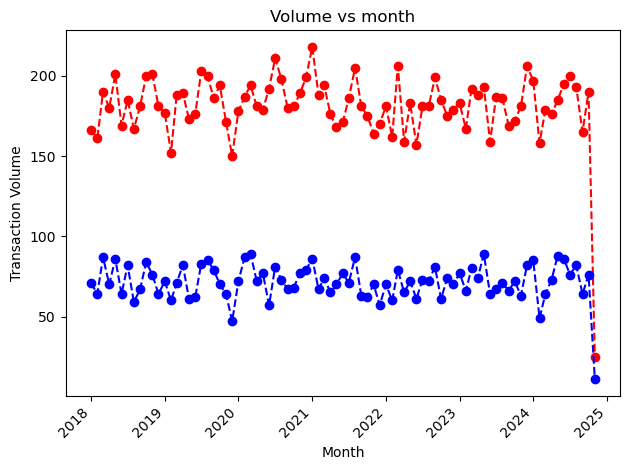

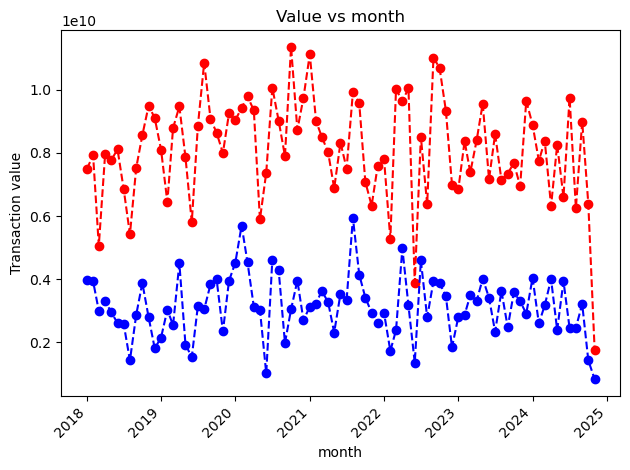

In [49]:
#visualizing trend

#volume vs month
plt.plot(trend['Month'].dt.to_timestamp(),trend['Volume'],linestyle='--',marker='o',color='r')
plt.plot(trend['Month'].dt.to_timestamp(),trend['Success_volume'],linestyle='--',marker='o',color='b')
plt.xlabel('Month')
plt.ylabel('Transaction Volume')
plt.title('Volume vs month')
plt.gcf().autofmt_xdate()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#value vs month

plt.plot(trend['Month'].dt.to_timestamp(),trend['Total_value'],linestyle='--',marker='o',color='r')
plt.plot(trend['Month'].dt.to_timestamp(),trend['Success_value'],linestyle='--',marker='o',color='b')
plt.xlabel('month')
plt.ylabel('Transaction value')
plt.title('Value vs month')
plt.gcf().autofmt_xdate()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

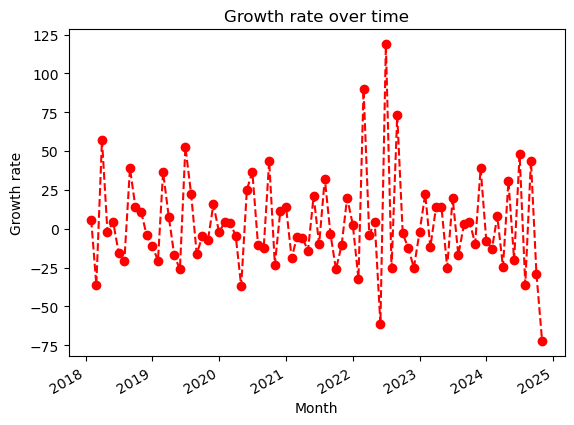

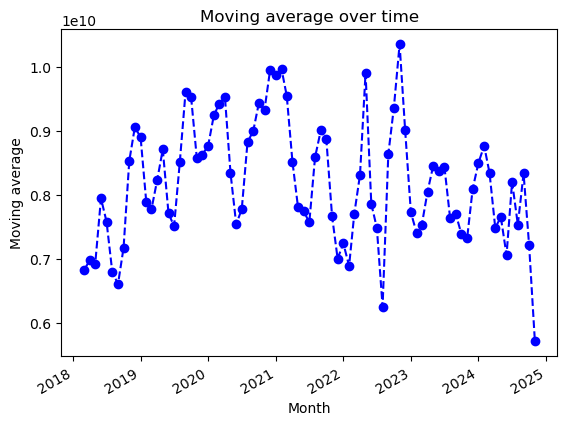

In [53]:
#GRowth rate vs moving average


plt.plot(trend['Month'].dt.to_timestamp(),trend['Growth_rate'],linestyle='--',color='r',marker='o')
plt.xlabel('Month')
plt.ylabel('Growth rate')
plt.title('Growth rate over time')
plt.gcf().autofmt_xdate()
plt.show()

plt.plot(trend['Month'].dt.to_timestamp(),trend['Moving_average'],linestyle='--',marker='o',color='b')
plt.xlabel('Month')
plt.ylabel('Moving average')
plt.title('Moving average over time')
plt.gcf().autofmt_xdate()
plt.show()

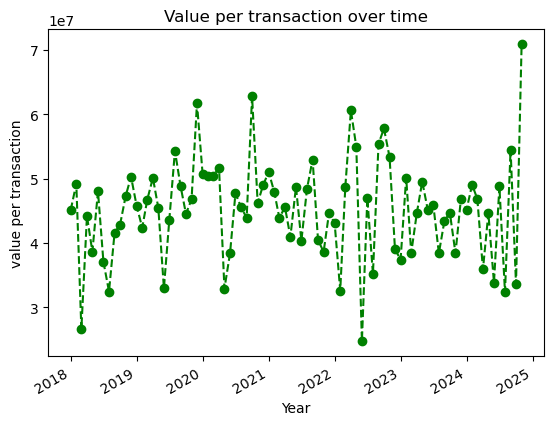

In [59]:
#Value per transaction

plt.plot(trend['Month'].dt.to_timestamp(),trend['Value_per_transaction'],linestyle='--',marker='o',color='g')
plt.gcf().autofmt_xdate()
plt.xlabel('Year')
plt.ylabel('value per transaction')
plt.title('Value per transaction over time')
plt.show()

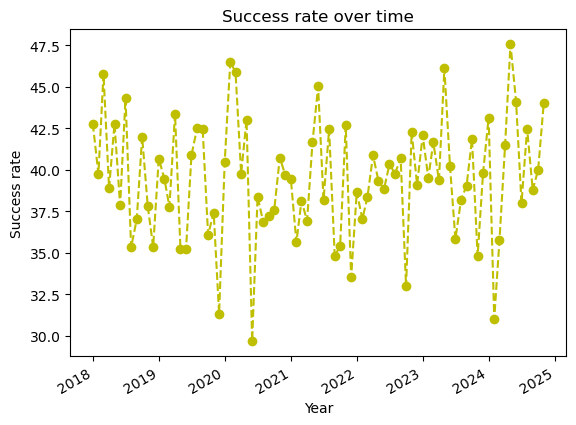

In [65]:
#Success rate trend

plt.plot(trend['Month'].dt.to_timestamp(),trend['Success_rate_vol'],linestyle='--',marker='o',color='y')
plt.gcf().autofmt_xdate()
plt.xlabel('Year')
plt.ylabel('Success rate')
plt.title('Success rate over time')
plt.show()

In [19]:
#Break trends by segments


#Transaction type segmentation

total_value=data.loc[
   data['Status']=='SUCCESS','Amount_in_INR'].sum()

t_segment=data.groupby('Transaction_Type').agg(
    total_txn_count=('Transaction_ID','count'),
    success_txn_count=('Status',lambda x: (x=='SUCCESS').sum()),
    failed_txn_count=('Status',lambda x:(x=='FAILED').sum()),
    pending_count=('Status',lambda x: (x=='PENDING').sum()),
    unk_count=('Status',lambda x: (x=='UNKNOWN').sum()),
    success_value=('Amount_in_INR',lambda x: x[ data.loc[x.index,'Status']=='SUCCESS'].sum())
).reset_index()

#summary

t_segment['success_rate']=(t_segment['success_txn_count']/t_segment['total_txn_count'])*100

t_segment['failure_rate']=(t_segment['failed_txn_count']/t_segment['total_txn_count'])*100

t_segment['pending_rate']=(t_segment['pending_count']/t_segment['total_txn_count'])*100

t_segment['unknown_rate']=(t_segment['unk_count']/t_segment['total_txn_count'])*100

t_segment['value_contribution']=(t_segment['success_value']/total_value)*100


print(t_segment)


#try piechart analysis

  Transaction_Type  total_txn_count  success_txn_count  failed_txn_count  \
0          DEPOSIT             5925               2356              1163   
1         TRANSFER             3054               1198               602   
2       WITHDRAWAL             6021               2367              1205   

   pending_count  unk_count  success_value  success_rate  failure_rate  \
0           1187       1219   1.086782e+11     39.763713     19.628692   
1            609        645   4.927947e+10     39.227243     19.711853   
2           1204       1245   1.028625e+11     39.312407     20.013287   

   pending_rate  unknown_rate  value_contribution  
0     20.033755     20.573840           41.667868  
1     19.941061     21.119843           18.894034  
2     19.996678     20.677628           39.438098  


Conclusion:
Deposit have high value contribution with 39% success rate ,19% failure rate, 20% unknown rate indicates operational inefficiencies across every transaction type even in Transfer contributing only 18% value contribution shows inefficiencies in operations

In [5]:
data1.head()

,customer_id,risk_segment,branch,transaction_type,status,amount_in_inr
0,CUST1000,Low risk,TRIVANDRUM,TRANSFER,SUCCESS,304416859
1,CUST1000,Low risk,TRIVANDRUM,DEPOSIT,SUCCESS,3768524
2,CUST1001,Medium risk,CHENNAI,WITHDRAWAL,FAILED,4863521
3,CUST1003,Low risk,TRIVANDRUM,DEPOSIT,SUCCESS,4573549
4,CUST1003,Low risk,TRIVANDRUM,WITHDRAWAL,UNKNOWN,1635773


In [25]:
#credit score based

total_success_amount=data1.loc[data1['status']=='SUCCESS','amount_in_inr'].sum()

c_segment=data1.groupby('risk_segment').agg(
    total_value= ('amount_in_inr','sum'),
    success_value= ('amount_in_inr',lambda x: x[data1.loc[x.index,'status']=='SUCCESS'].sum()),
    success_count= ('status',lambda x: (x=='SUCCESS').sum()),
    failed_count= ('status',lambda x: (x=='FAILED').sum()),
    pending_count= ('status',lambda x: (x=='PENDING').sum()),
    total_count=('customer_id','count')
)


c_segment['success_rate']=(c_segment['success_count']/c_segment['total_count'])*100

c_segment['failed_rate']=(c_segment['failed_count']/c_segment['total_count'])*100

c_segment['pending_rate']=(c_segment['pending_count']/c_segment['total_count'])*100

c_segment['success_value_rate']=(c_segment['success_value']/c_segment['total_value'])*100

c_segment['contribution']=(c_segment['success_value']/total_success_amount)*100


print(c_segment)

               total_value  success_value  success_count  failed_count  \
risk_segment                                                             
High Risk     193275241024    72366214724           1663           836   
Low risk      132311803073    56292272791           1165           607   
Medium risk    73464376126    28706197148            626           331   

              pending_count  total_count  success_rate  failed_rate  \
risk_segment                                                          
High Risk               853         4190     39.689737    19.952267   
Low risk                588         2977     39.133356    20.389654   
Medium risk             310         1638     38.217338    20.207570   

              pending_rate  success_value_rate  contribution  
risk_segment                                                  
High Risk        20.357995           37.442051     45.986312  
Low risk         19.751428           42.545163     35.771859  
Medium risk      18.9

In [14]:
#high_value ,abnormal , negative transactions

#High_valued transactions

threshold=data['Amount_in_INR'].quantile(0.95)

High_valued_txns=data[data['Amount_in_INR']>=threshold]
High_valued_txns=pd.DataFrame(High_valued_txns)
#print(High_valued_txns)

#print(High_valued_txns.columns[High_valued_txns.columns.duplicated()].tolist())
summary={
    'Total_txn':len(High_valued_txns),
    'Success_txn':(High_valued_txns['Status']=='SUCCESS').sum(),
    'Failed_txn':(High_valued_txns['Status']=='FAILED').sum(),
    'pending_txn':(High_valued_txns['Status']=='PENDING').sum(),
    'Unknwon_txn':(High_valued_txns['Status']=='UNKNOWN').sum()
}

summary['failed_rate']=(summary['Failed_txn']/summary['Total_txn'])*100

summary['Pending_rate']=(summary['pending_txn']/summary['Total_txn'])*100
summary_df=pd.DataFrame([summary])
print(summary)

#negative valued transactions

negative_txns=data[data['Amount_in_INR']<0]

#print(negative_txns)


#abnormal transactions

Q1=data['Amount_in_INR'].quantile(0.25)
Q3=data['Amount_in_INR'].quantile(0.75)

IQR=Q3-Q1

lower_bound=Q1-(1.5*IQR)
upper_bound=Q3+(1.5*IQR)

abnormal_txn=data[
    (data['Amount_in_INR']<lower_bound) | 
    (data['Amount_in_INR']>upper_bound)
]

#print(abnormal_txn)

print('Abnormal TXN',abnormal_txn.groupby(['Transaction_Type','Status']).size())
print('High_valued txns',High_valued_txns.groupby(['Transaction_Type','Status']).size())
print('Negative txns',negative_txns.groupby(['Transaction_Type','Status']).size())

{'Total_txn': 750, 'Success_txn': 281, 'Failed_txn': 157, 'pending_txn': 147, 'Unknwon_txn': 165, 'failed_rate': 20.933333333333334, 'Pending_rate': 19.6}
Abnormal TXN Transaction_Type  Status 
DEPOSIT           FAILED     240
                  PENDING    237
                  SUCCESS    470
                  UNKNOWN    246
TRANSFER          FAILED     117
                  PENDING    112
                  SUCCESS    218
                  UNKNOWN    144
WITHDRAWAL        FAILED     252
                  PENDING    243
                  SUCCESS    479
                  UNKNOWN    264
dtype: int64
High_valued txns Transaction_Type  Status 
DEPOSIT           FAILED      61
                  PENDING     60
                  SUCCESS    123
                  UNKNOWN     54
TRANSFER          FAILED      35
                  PENDING     24
                  SUCCESS     55
                  UNKNOWN     41
WITHDRAWAL        FAILED      61
                  PENDING     63
                  SUCCES

In [79]:
#High value transaction segmentation

threshold=data1['amount_in_inr'].quantile(0.95)
HV_txn=data1[data1['amount_in_inr']>=threshold]
HV_txn=pd.DataFrame(HV_txn)

overall_txn_value=HV_txn['amount_in_inr'].sum()
overall_suc_value=HV_txn[HV_txn['status']=='SUCCESS']['amount_in_inr'].sum()
summary1=HV_txn.groupby('risk_segment').agg(
    total_txn=('customer_id','count'),
    success_txn=('status',lambda x:(x=='SUCCESS').sum()),
    failed_txn=('status',lambda x: (x=='FAILED').sum()),
    pending_txn=('status',lambda x:(x=='PENDING').sum()),
    unk_txn=('status',lambda x:(x=='UNKNOWN').sum()),
    total_value=('amount_in_inr','sum'),
    Success_value=('amount_in_inr',lambda x:x[HV_txn.loc[x.index,'status']=='SUCCESS'].sum()),
    failed_value=('amount_in_inr',lambda x: x[HV_txn.loc[x.index,'status']=='FAILED'].sum())
).reset_index()

summary1['success_rate']=(summary1['success_txn']/summary1['total_txn'])*100

summary1['failed_rate']=(summary1['failed_txn']/summary1['total_txn'])*100

summary1['pending_rate']=(summary1['pending_txn']/summary1['total_txn'])*100

summary1['value_contribution']=(summary1['total_value']/overall_txn_value)*100

summary1['suc_val_contribution']=(summary1['Success_value']/overall_suc_value)*100

summary1['Avg_ticket']=summary1['total_value']/summary1['total_txn']

summary1['Avg_failed_amnt']=summary1['failed_value']/summary1['failed_txn']

summary1['Efficiency_ratio']=summary1['Success_value']/summary1['total_value']

summary1['Expected_loss']=summary1['failed_rate']*summary1['Avg_ticket']*summary1['total_txn']
print(summary1)

  risk_segment  total_txn  success_txn  failed_txn  pending_txn  unk_txn  \
0    High Risk        224           83          51           43       47   
1     Low risk        135           57          32           17       29   
2  Medium risk         82           33          13           11       25   

   total_value  Success_value  failed_value  success_rate  failed_rate  \
0  81933813374    30219225233   18590258245     37.053571    22.767857   
1  48610123620    20526883799   11648561213     42.222222    23.703704   
2  29542009143    12032284572    4576337219     40.243902    15.853659   

   pending_rate  value_contribution  suc_val_contribution    Avg_ticket  \
0     19.196429           51.181141             48.136347  3.657760e+08   
1     12.592593           30.365016             32.697370  3.600750e+08   
2     13.414634           18.453843             19.166283  3.602684e+08   

   Avg_failed_amnt  Efficiency_ratio  Expected_loss  
0     3.645149e+08          0.368825   1.86

Conclusion:

~ High-risk customers are dominant driver of both exposure and expected loss (50% of EL) , making the portfolio's biggest vulnerability and average failed
amount in similar in every segments but High risk segment has most failed txns which will highly in expected loss
~ Low_risk customers have higher efficiency and contribute dispropotionally to successfull value 
~ Medium-risk customers are even shorter in number but has lowest failed rate and lowest expected loss and having relatively higher efficiency not much lesser compared to Low risk
~ Prioritising Low risk and Medium risk customers will help to improve in growth 
~ operational inefficiencies are evident 

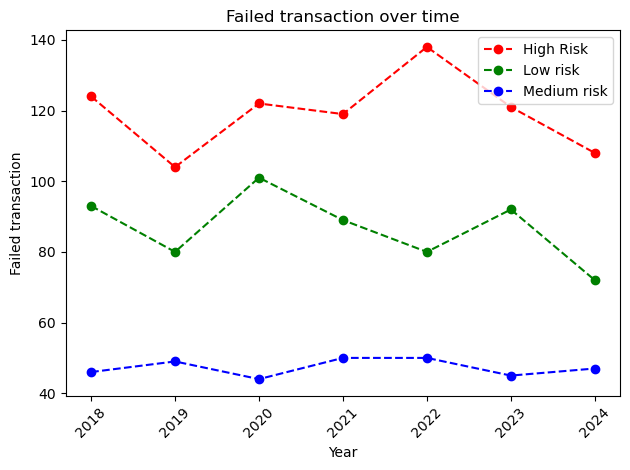

In [7]:
#trend risk segment with txn status over time
colors={
    'High Risk':'Red',
    'Low risk':'Green',
    'Medium risk':'Blue'
}

for segment, group in data2.groupby('risk_segment'):
    plt.plot(group['year'],group['failed_txn'],label=segment,color=colors[segment],linestyle='--',marker='o')
plt.xlabel('Year')
plt.ylabel('Failed transaction')
plt.title('Failed transaction over time')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

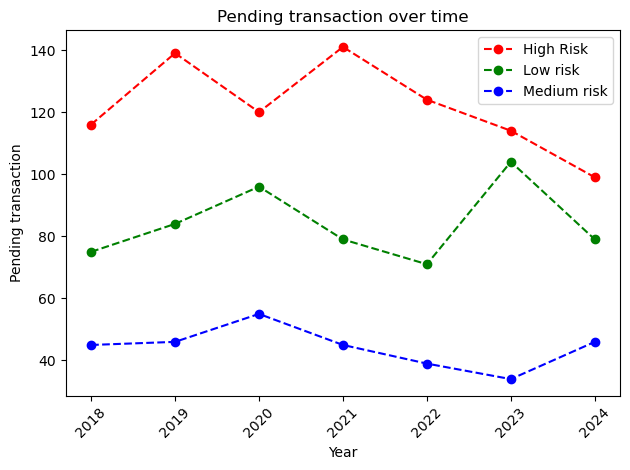

In [9]:
#trend risk segment with txn status over time
colors={
    'High Risk':'Red',
    'Low risk':'Green',
    'Medium risk':'Blue'
}

for segment, group in data2.groupby('risk_segment'):
    plt.plot(group['year'],group['pending_txn'],label=segment,color=colors[segment],linestyle='--',marker='o')
plt.xlabel('Year')
plt.ylabel('Pending transaction')
plt.title('Pending transaction over time')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

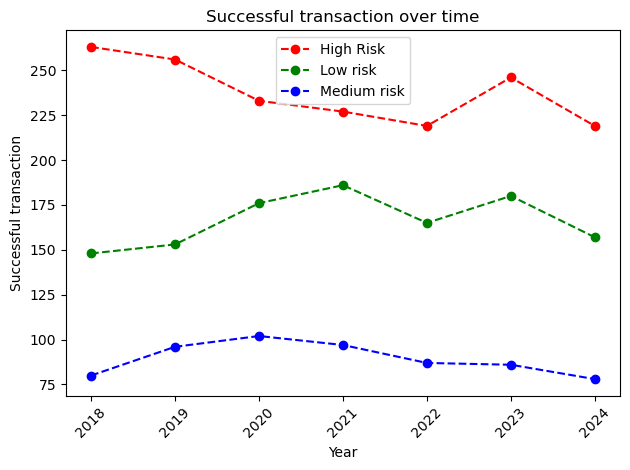

In [11]:
#trend risk segment with txn status over time
colors={
    'High Risk':'Red',
    'Low risk':'Green',
    'Medium risk':'Blue'
}

for segment, group in data2.groupby('risk_segment'):
    plt.plot(group['year'],group['success_txn'],label=segment,color=colors[segment],linestyle='--',marker='o')
plt.xlabel('Year')
plt.ylabel('Successful transaction')
plt.title('Successful transaction over time')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Conclusion:

analysis shows that high risk customers consistently exhibit higher failed and pending transaction volumes along with declining successfull transactions, indicating increased operational and fraud related risk 
~in contrast,low risk customers maintain stronger transaction stability and higher completion efficiency , making them most reliable segment over time
~Medium risk customers also stable but moderate-performing segment , could potentially migrate toward low-risk behavour with proper controls

pattern:

In higher valued transactions - 20% failed and 20% pending and 37% success rate : indicates significant operational ineffeciency 
large transactions failing frequently 

In [26]:
#Abnormal transaction data
print(abnormal_txn)

#credit-abnormal
Q1=data1['amount_in_inr'].quantile(0.25)
Q3=data1['amount_in_inr'].quantile(0.75)

IQR=Q3-Q1

lower_bound=Q1-(1.5*IQR)
upper_bound=Q3+(1.5*IQR)

abnormal_txn_c=data1[
    (data1['amount_in_inr']<lower_bound) |
    (data1['amount_in_inr']>upper_bound)
]
#segment 1
s1=abnormal_txn.groupby(['Transaction_Type','Status']).size()
print(s1)

#credit segment
s2=abnormal_txn_c.groupby('risk_segment').size()

print(s2)

      Transaction_ID Customer_ID      Branch Transaction_Date  \
1          TXN659381    CUST9640     CHENNAI       2019-01-12   
3          TXN823601    CUST2120       KOCHI       2020-12-18   
9          TXN381025    CUST8176       KOCHI       2023-12-28   
11         TXN352057    CUST5495  TRIVANDRUM       2021-05-18   
12         TXN648395    CUST4363     CALICUT       2019-06-07   
...              ...         ...         ...              ...   
14985      TXN622148    CUST3901       KOCHI       2022-07-13   
14986      TXN732184    CUST9247  TRIVANDRUM       2020-12-12   
14987      TXN507060    CUST1679     CALICUT       2021-12-15   
14989      TXN473575    CUST4137       KOCHI       2022-03-08   
14992      TXN978341    CUST6366     CHENNAI       2020-11-12   

      Transaction_Type     Amount Currency   Status  Amount_in_INR  
1           WITHDRAWAL  3793001.0      USD  PENDING    314819083.0  
3           WITHDRAWAL  1180522.0      USD  SUCCESS     97983326.0  
9           

In [32]:
#Negative transactions

negative_txn=data[data['Amount_in_INR']<0]

print(negative_txn.groupby(['Transaction_Type','Status']).size())

Transaction_Type  Status 
DEPOSIT           FAILED     10
                  PENDING    10
                  SUCCESS    27
                  UNKNOWN    21
TRANSFER          FAILED      4
                  PENDING     6
                  SUCCESS     8
                  UNKNOWN     6
WITHDRAWAL        FAILED      7
                  PENDING    15
                  SUCCESS    21
                  UNKNOWN    17
dtype: int64


Conclusion:
while many negative transactions successfully completed(refunds and reversals) , a significantly proportion of -ve txns remain pending and unknown
~which indicates reconciliation inefficiency and settlement delays 
~withdrawal and deposit reversals show the highest irregularity a